<a href="https://colab.research.google.com/github/zergswim/Diffusion_Study/blob/main/Positional_Embedding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using Device: cpu
Image Patches: 16 patches (Patch size: 7x7)


100%|██████████| 9.91M/9.91M [00:00<00:00, 16.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]



 Training Start: ViT WITH Positional Embedding
Epoch [01/10] - Loss: 0.5227 | Test Accuracy: 94.42%
Epoch [02/10] - Loss: 0.2045 | Test Accuracy: 95.65%
Epoch [03/10] - Loss: 0.1625 | Test Accuracy: 96.28%
Epoch [04/10] - Loss: 0.1408 | Test Accuracy: 96.82%
Epoch [05/10] - Loss: 0.1240 | Test Accuracy: 96.77%
Epoch [06/10] - Loss: 0.1139 | Test Accuracy: 97.30%
Epoch [07/10] - Loss: 0.1038 | Test Accuracy: 97.28%
Epoch [08/10] - Loss: 0.0967 | Test Accuracy: 97.52%
Epoch [09/10] - Loss: 0.0920 | Test Accuracy: 97.68%
Epoch [10/10] - Loss: 0.0849 | Test Accuracy: 97.48%
>> ViT WITH Positional Embedding 완료 (486.85초) | 최종 정확도: 97.48%


 Training Start: ViT WITHOUT Positional Embedding
Epoch [01/10] - Loss: 0.9359 | Test Accuracy: 84.23%
Epoch [02/10] - Loss: 0.4991 | Test Accuracy: 87.88%
Epoch [03/10] - Loss: 0.4025 | Test Accuracy: 90.67%
Epoch [04/10] - Loss: 0.3442 | Test Accuracy: 91.71%
Epoch [05/10] - Loss: 0.3126 | Test Accuracy: 92.58%
Epoch [06/10] - Loss: 0.2854 | Test Accura

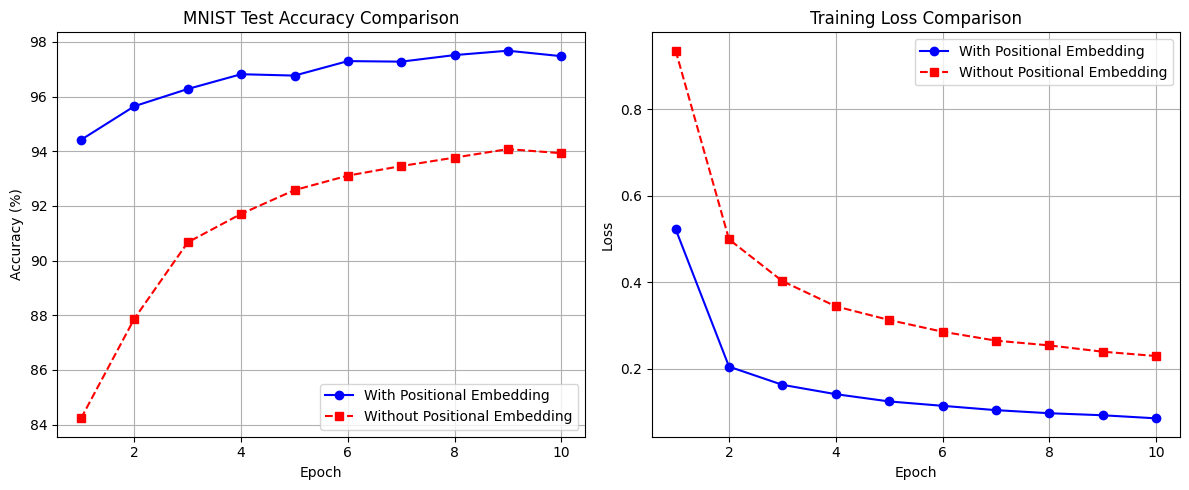

In [ ]:
# ==============================================================================
# Vision Transformer (ViT) Positional Embedding vs Non-Positional Embedding
# Compatible with Python 3.13 / PyTorch 2.x (Google Colab)
# ==============================================================================

import time
import math
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. 하이퍼파라미터 및 디바이스 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 1e-3

IMAGE_SIZE = 28
PATCH_SIZE = 7  # 28 / 7 = 4x4 (총 16개 패치)
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2  # 16
PATCH_DIM = 1 * PATCH_SIZE * PATCH_SIZE        # 49차원
EMBED_DIM = 64
NUM_HEADS = 4
DEPTH = 2
NUM_CLASSES = 10

print(f"Using Device: {DEVICE}")
print(f"Image Patches: {NUM_PATCHES} patches (Patch size: {PATCH_SIZE}x{PATCH_SIZE})")

# 2. Vision Transformer (ViT) 아키텍처 구현
class SimpleViT(nn.Module):
    def __init__(self, patch_size=7, in_channels=1, num_classes=10,
                 embed_dim=64, depth=2, heads=4, mlp_dim=128,
                 use_pos_embedding=True):
        super().__init__()
        self.patch_size = patch_size
        self.use_pos_embedding = use_pos_embedding
        num_patches = (28 // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        # [Q, K, V의 시작] Raw Pixel 패치를 Latent 임베딩 공간으로 투영 (Linear Projection)
        self.patch_to_embedding = nn.Linear(patch_dim, embed_dim)

        # CLS 토큰 (전체 이미지를 대표하는 요약 토큰)
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        # 학습 가능한 포지셔널 임베딩 (CLS 토큰 + 16개 패치 = 총 17개 위치)
        if self.use_pos_embedding:
            self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))

        # Transformer Encoder Block (Self-Attention)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # 최종 분류 헤드
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # 1) 패치 분할: (B, 1, 28, 28) -> (B, 16, 49)
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * p * p)

        # 2) 임베딩 벡터로 변환 (Q, K, V 입력 전단계)
        x = self.patch_to_embedding(x)

        # 3) CLS 토큰 결합
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)  # (B, 17, 64)

        # 4) 포지셔널 임베딩 주입 여부 (핵심 비교 포인트!)
        if self.use_pos_embedding:
            x = x + self.pos_embedding

        # 5) Q, K, V 연산을 통한 Self-Attention 수행
        x = self.transformer(x)

        # 6) CLS 토큰 출력값을 통한 분류
        cls_output = x[:, 0]
        return self.mlp_head(cls_output)

# 3. MNIST 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 4. 학습 및 평가 함수
def train_and_evaluate(model, name, train_loader, test_loader, epochs=EPOCHS):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    train_losses, test_accuracies = [], []

    print(f"\n==========================================")
    print(f" Training Start: {name}")
    print(f"==========================================")
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # 검증
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        test_accuracies.append(accuracy)
        print(f"Epoch [{epoch:02d}/{epochs:02d}] - Loss: {epoch_loss:.4f} | Test Accuracy: {accuracy:.2f}%")

    elapsed = time.time() - start_time
    print(f">> {name} 완료 ({elapsed:.2f}초) | 최종 정확도: {test_accuracies[-1]:.2f}%\n")
    return train_losses, test_accuracies

# 5. 두 모델 비교 실험 실행
# 모델 A: 포지셔널 임베딩 적용 (With PE)
model_with_pe = SimpleViT(use_pos_embedding=True)
loss_pe, acc_pe = train_and_evaluate(model_with_pe, "ViT WITH Positional Embedding", train_loader, test_loader)

# 모델 B: 포지셔널 임베딩 미적용 (Without PE)
model_no_pe = SimpleViT(use_pos_embedding=False)
loss_no_pe, acc_no_pe = train_and_evaluate(model_no_pe, "ViT WITHOUT Positional Embedding", train_loader, test_loader)

# 6. 순열 불변성(Permutation Invariance) 실증 테스트
def test_permutation_invariance(model, loader, name):
    model.eval()
    p = 7
    diff_list = []

    with torch.no_grad():
        for images, _ in loader:
            images = images.to(DEVICE)
            B = images.shape[0]

            # 원본 이미지 모델 출력
            out_orig = model(images)

            # 패치를 추출한 뒤 무작위로 위치 셔플(Permute)
            x = images.unfold(2, p, p).unfold(3, p, p)
            patches = x.contiguous().view(B, 1, -1, p, p).permute(0, 2, 1, 3, 4).contiguous().view(B, 16, 49)

            # 16개 패치 순서를 무작위 셔플
            perm = torch.randperm(16)
            patches_permuted = patches[:, perm, :]

            # 셔플된 패치로 이미지 재구성
            permuted_images = patches_permuted.view(B, 4, 4, 1, p, p).permute(0, 3, 1, 4, 2, 5).contiguous().view(B, 1, 28, 28)

            # 셔플된 이미지 모델 출력
            out_permuted = model(permuted_images)

            # 로짓 변화 차이 계산
            diff = (out_orig - out_permuted).abs().max(dim=1)[0].mean().item()
            diff_list.append(diff)
            break

    print(f"[{name}] 이미지 패치 셔플 후 모델 출력(Logit) 변화량: {np.mean(diff_list):.8f}")

print("==========================================")
print(" Permutation Invariance Proof Test")
print("==========================================")
test_permutation_invariance(model_with_pe, test_loader, "ViT WITH PE")
test_permutation_invariance(model_no_pe, test_loader, "ViT WITHOUT PE")

# 7. 시각화 그래프 출력
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, EPOCHS + 1), acc_pe, 'o-', label="With Positional Embedding", color='blue')
plt.plot(range(1, EPOCHS + 1), acc_no_pe, 's--', label="Without Positional Embedding", color='red')
plt.title("MNIST Test Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, EPOCHS + 1), loss_pe, 'o-', label="With Positional Embedding", color='blue')
plt.plot(range(1, EPOCHS + 1), loss_no_pe, 's--', label="Without Positional Embedding", color='red')
plt.title("Training Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


 🔍 [분석 결과] ViT WITH Positional Embedding
숫자 0 분류 정확도: 98.88%
숫자 1 분류 정확도: 99.12%
숫자 2 분류 정확도: 97.00%
숫자 3 분류 정확도: 98.02%
숫자 4 분류 정확도: 97.86%
숫자 5 분류 정확도: 95.63%
숫자 6 분류 정확도: 98.12%
숫자 7 분류 정확도: 97.47%
숫자 8 분류 정확도: 97.23%
숫자 9 분류 정확도: 95.14%
------------------------------------------
💡 [공간 인지 실패(형태 착각) 주요 사례]
 - 정답 '6'을 '9'로 오해: 0회
 - 정답 '9'를 '6'으로 오해: 0회
 - 정답 '2'를 '5'로 오해: 0회
 - 정답 '5'를 '2'로 오해: 1회


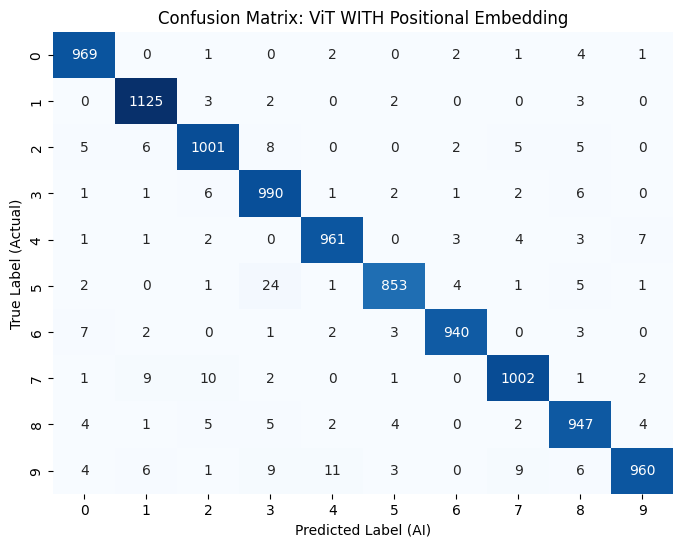


 🔍 [분석 결과] ViT WITHOUT Positional Embedding
숫자 0 분류 정확도: 94.18%
숫자 1 분류 정확도: 99.03%
숫자 2 분류 정확도: 95.25%
숫자 3 분류 정확도: 94.75%
숫자 4 분류 정확도: 94.20%
숫자 5 분류 정확도: 89.46%
숫자 6 분류 정확도: 93.84%
숫자 7 분류 정확도: 96.21%
숫자 8 분류 정확도: 86.76%
숫자 9 분류 정확도: 94.15%
------------------------------------------
💡 [공간 인지 실패(형태 착각) 주요 사례]
 - 정답 '6'을 '9'로 오해: 4회
 - 정답 '9'를 '6'으로 오해: 1회
 - 정답 '2'를 '5'로 오해: 10회
 - 정답 '5'를 '2'로 오해: 40회


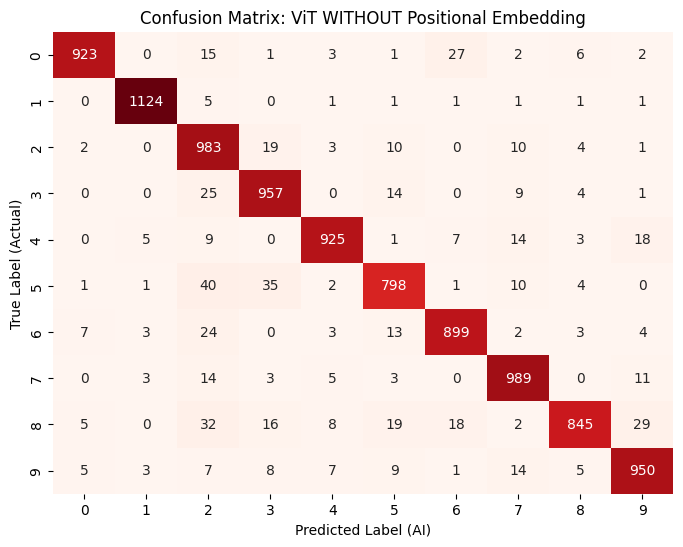

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

def analyze_class_confusion(model, test_loader, name):
    model.eval()
    all_preds = []
    all_labels = []

    # 테스트 데이터셋 전체 예측 수행
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # 혼동 행렬(Confusion Matrix) 계산
    cm = confusion_matrix(all_labels, all_preds)

    # 클래스별 정확도 도출
    class_accuracy = cm.diagonal() / cm.sum(axis=1) * 100

    # 주요 타겟(형태가 유사하고 배치가 다른 숫자) 간의 치명적 오답 횟수 추출
    conf_6_to_9 = cm[6][9] # 정답이 6인데 9로 예측한 횟수
    conf_9_to_6 = cm[9][6] # 정답이 9인데 6으로 예측한 횟수
    conf_2_to_5 = cm[2][5] # 정답이 2인데 5로 예측한 횟수
    conf_5_to_2 = cm[5][2] # 정답이 5인데 2로 예측한 횟수

    # 결과 출력
    print(f"\n==========================================")
    print(f" 🔍 [분석 결과] {name}")
    print(f"==========================================")
    for i in range(10):
        print(f"숫자 {i} 분류 정확도: {class_accuracy[i]:.2f}%")

    print("-" * 42)
    print(f"💡 [공간 인지 실패(형태 착각) 주요 사례]")
    print(f" - 정답 '6'을 '9'로 오해: {conf_6_to_9}회")
    print(f" - 정답 '9'를 '6'으로 오해: {conf_9_to_6}회")
    print(f" - 정답 '2'를 '5'로 오해: {conf_2_to_5}회")
    print(f" - 정답 '5'를 '2'로 오해: {conf_5_to_2}회")

    # 혼동 행렬 시각화 (히트맵)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds' if 'WITHOUT' in name else 'Blues', cbar=False)
    plt.title(f"Confusion Matrix: {name}")
    plt.xlabel("Predicted Label (AI)")
    plt.ylabel("True Label (Actual)")
    plt.show()

# 1. 포지셔널 임베딩이 적용된 정상 모델 분석
analyze_class_confusion(model_with_pe, test_loader, "ViT WITH Positional Embedding")

# 2. 포지셔널 임베딩이 제거된 모델 분석 (가설 검증 대상)
analyze_class_confusion(model_no_pe, test_loader, "ViT WITHOUT Positional Embedding")


 Training Start: ViT WITH CLS Token
Epoch [1/5] - Test Accuracy: 94.15%
Epoch [2/5] - Test Accuracy: 95.84%
Epoch [3/5] - Test Accuracy: 96.89%
Epoch [4/5] - Test Accuracy: 96.86%
Epoch [5/5] - Test Accuracy: 96.95%

 Training Start: ViT WITH Global Average Pooling (No CLS)
Epoch [1/5] - Test Accuracy: 95.09%
Epoch [2/5] - Test Accuracy: 96.42%
Epoch [3/5] - Test Accuracy: 96.78%
Epoch [4/5] - Test Accuracy: 97.14%
Epoch [5/5] - Test Accuracy: 97.34%


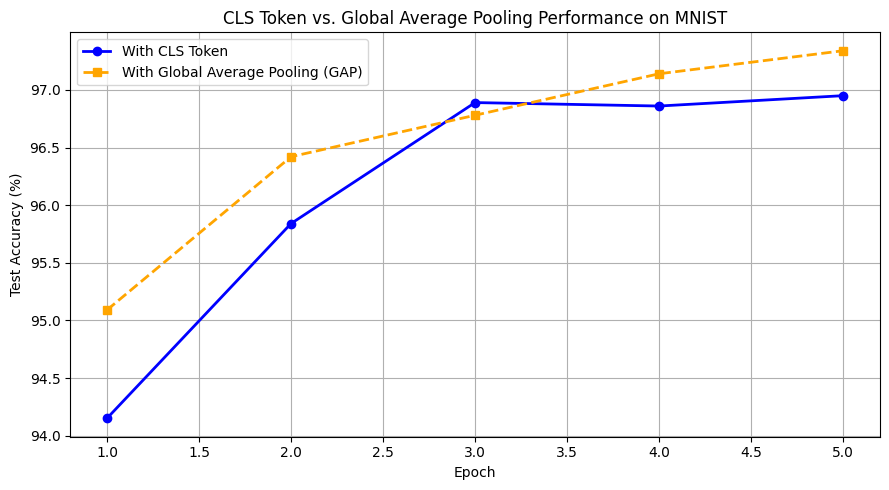

In [3]:
# ==============================================================================
# ViT Comparison: CLS Token vs. Global Average Pooling (GAP) on MNIST
# Compatible with Python 3.13 / PyTorch 2.x (Google Colab)
# ==============================================================================

import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 1. 하이퍼파라미터 및 디바이스 설정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128
EPOCHS = 5  # 빠른 비교를 위해 5 에포크 설정
LEARNING_RATE = 1e-3

# 2. MNIST 데이터셋 로드
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 3. 통합 Vision Transformer 아키텍처 (use_cls 파라미터로 모드 전환)
class ViTComparison(nn.Module):
    def __init__(self, patch_size=7, in_channels=1, num_classes=10,
                 embed_dim=64, depth=2, heads=4, mlp_dim=128, use_cls=True):
        super().__init__()
        self.patch_size = patch_size
        self.use_cls = use_cls
        num_patches = (28 // patch_size) ** 2
        patch_dim = in_channels * patch_size * patch_size

        # 패치 선형 투영 (Patch Projection)
        self.patch_to_embedding = nn.Linear(patch_dim, embed_dim)

        if self.use_cls:
            # CLS 토큰 방식: 토큰 개수 + 1, CLS 파라미터 추가 생성
            self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
            self.pos_embedding = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        else:
            # 풀링 방식: 순수 패치 개수(16개)만큼만 포지셔널 임베딩 할당
            self.pos_embedding = nn.Parameter(torch.randn(1, num_patches, embed_dim))

        # 트랜스포머 인코더 블록
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim,
            nhead=heads,
            dim_feedforward=mlp_dim,
            batch_first=True,
            activation='gelu'
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)

        # 최종 분류 헤드
        self.mlp_head = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.patch_size

        # 패치 추출 및 평탄화: (B, 1, 28, 28) -> (B, 16, 49)
        x = x.unfold(2, p, p).unfold(3, p, p)
        x = x.contiguous().view(B, C, -1, p, p)
        x = x.permute(0, 2, 1, 3, 4).contiguous().view(B, -1, C * p * p)

        # 임베딩 변환
        x = self.patch_to_embedding(x)

        if self.use_cls:
            # CLS 토큰 결합 및 PE 더하기
            cls_tokens = self.cls_token.expand(B, -1, -1)
            x = torch.cat((cls_tokens, x), dim=1)  # (B, 17, embed_dim)
            x = x + self.pos_embedding
            x = self.transformer(x)
            representation = x[:, 0]  # 첫 번째 토큰(CLS) 추출
        else:
            # 순수 패치에만 PE 더하기
            x = x + self.pos_embedding             # (B, 16, embed_dim)
            x = self.transformer(x)
            representation = x.mean(dim=1)         # 전역 평균 풀링(GAP) 적용

        return self.mlp_head(representation)

# 4. 학습 및 평가 루프 함수
def train_and_evaluate(model, name):
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

    accuracies = []
    print(f"\n==========================================")
    print(f" Training Start: {name}")
    print(f"==========================================")

    for epoch in range(1, EPOCHS + 1):
        model.train()
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

        # 검증 평가
        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total
        accuracies.append(accuracy)
        print(f"Epoch [{epoch}/{EPOCHS}] - Test Accuracy: {accuracy:.2f}%")

    return accuracies

# 5. 모델 두 개 실행 (CLS Token vs Global Average Pooling)
model_with_cls = ViTComparison(use_cls=True)
acc_cls = train_and_evaluate(model_with_cls, "ViT WITH CLS Token")

model_with_gap = ViTComparison(use_cls=False)
acc_gap = train_and_evaluate(model_with_gap, "ViT WITH Global Average Pooling (No CLS)")

# 6. 결과 시각화 비교
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), acc_cls, 'o-', label="With CLS Token", color='blue', linewidth=2)
plt.plot(range(1, EPOCHS + 1), acc_gap, 's--', label="With Global Average Pooling (GAP)", color='orange', linewidth=2)
plt.title("CLS Token vs. Global Average Pooling Performance on MNIST")
plt.xlabel("Epoch")
plt.ylabel("Test Accuracy (%)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()